<a href="https://colab.research.google.com/github/Krish7grg/Cn6005-PortfolioAI/blob/main/Week_4_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    174.2           55.0           35.3      7.4  27.4   
1          0.0    127.9           47.9           39.7    238.8  36.3   
2         10.1     82.6           81.3            6.1     70.0  34.1   
3          6.0     96.0           35.9           15.3    209.5  25.0   
4          3.4    135.9           89.3           24.5     63.0  34.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.200  22.2        1  
1                     0.300  42.8        0  
2                     0.700  27.3        1  
3                     0.078  37.0        1  
4                     0.400  29.6        1  
Outcome
1    3320
0    1680
Name: count, dtype: int64
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5293 - loss: 0.9420 - val_accuracy: 0.6700 - val_loss: 0.8151
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6201 - loss: 0.8306 - val_accuracy: 0.6775 - val_loss: 0.7740
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6499 - loss: 0.7799 - val_accuracy: 0.6775 - val_loss: 0.7436
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6598 - loss: 0.7500 - val_accuracy: 0.6775 - val_loss: 0.7200
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6657 - loss: 0.7316 - val_accuracy: 0.6775 - val_loss: 0.7005
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6667 - loss: 0.7054 - val_accuracy: 0.6775 - val_loss: 0.6852
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6717 - loss: 0.6879 - val_accuracy: 0.6775 - val_loss: 0.6731
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6700 - loss: 0.6760 - val_accuracy: 0.6775

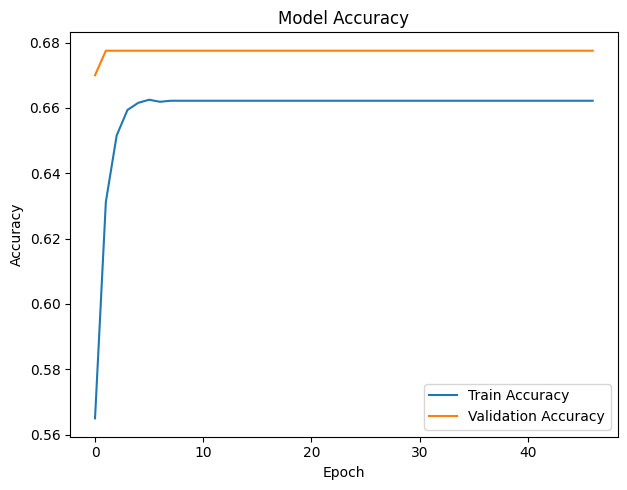

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       341
           1       0.66      1.00      0.79       659

    accuracy                           0.66      1000
   macro avg       0.33      0.50      0.40      1000
weighted avg       0.43      0.66      0.52      1000

[[  0 341]
 [  0 659]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
#load the dataset
df = pd.read_csv('Diabetes_ANN.csv')

print(type(df))

print(df.head())
class_counts = df['Outcome'].value_counts()

# Display the result
print(class_counts)
# Separate features and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the ANN model
model = Sequential([

 Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],),
          kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')

   ])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

# Predict on test data
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))



Class distribution BEFORE SMOTE:
 Outcome
1    2661
0    1339
Name: count, dtype: int64
Class distribution AFTER SMOTE:
 Outcome
1    2661
0    2661
Name: count, dtype: int64
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5580 - loss: 0.8780 - val_accuracy: 0.0141 - val_loss: 0.9910
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5995 - loss: 0.8028 - val_accuracy: 0.0000e+00 - val_loss: 0.9702
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5973 - loss: 0.7658 - val_accuracy: 0.0000e+00 - val_loss: 0.9588
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6160 - loss: 0.7286 - val_accuracy: 0.0000e+00 - val_loss: 0.9606
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6257 - loss: 0.7051 - val_accuracy: 0.0000e+00 - val_loss: 0.9629
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6237 - loss: 0.6903 - val_accuracy: 0.0000e+00 - val_loss: 0.9613
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6253 - loss: 0.6838 - val_accuracy: 0.0000e+00 - val_loss: 0.9659
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6147 - loss: 0.681

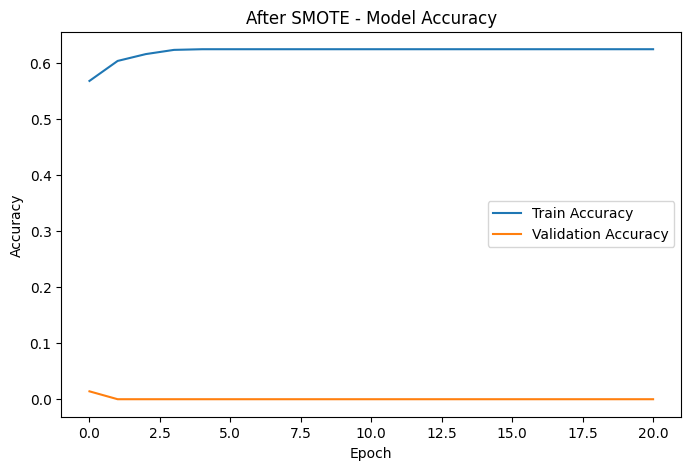

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report (After SMOTE):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       341
           1       0.66      1.00      0.79       659

    accuracy                           0.66      1000
   macro avg       0.33      0.50      0.40      1000
weighted avg       0.43      0.66      0.52      1000

Confusion Matrix (After SMOTE):
 [[  0 341]
 [  0 659]]


In [ ]:
#Oversampling

!pip install imblearn

from imblearn.over_sampling import SMOTE




# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution BEFORE SMOTE:\n", y_train.value_counts())
print("Class distribution AFTER SMOTE:\n", pd.Series(y_train_sm).value_counts())

# Build ANN model
model_sm = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_sm.shape[1],),
          kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile model
model_sm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop_sm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history_sm = model_sm.fit(X_train_sm, y_train_sm, epochs=100, batch_size=32,
                          validation_split=0.2, callbacks=[early_stop_sm], verbose=1)

# Plot accuracy
plt.figure(figsize=(8,5))
plt.plot(history_sm.history['accuracy'], label='Train Accuracy')
plt.plot(history_sm.history['val_accuracy'], label='Validation Accuracy')
plt.title('After SMOTE - Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Predictions
y_pred_prob_sm = model_sm.predict(X_test_scaled)
y_pred_sm = (y_pred_prob_sm > 0.5).astype("int32")

# Evaluation
print("Classification Report (After SMOTE):\n", classification_report(y_test, y_pred_sm, zero_division=0))
print("Confusion Matrix (After SMOTE):\n", confusion_matrix(y_test, y_pred_sm))


Class distribution BEFORE SMOTE:
 Outcome
1    2661
0    1339
Name: count, dtype: int64
Class distribution AFTER SMOTE:
 Outcome
1    2661
0    2661
Name: count, dtype: int64
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5622 - loss: 14.7316 - val_accuracy: 0.0376 - val_loss: 6.5832
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5587 - loss: 5.0564 - val_accuracy: 0.1305 - val_loss: 2.5893
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5204 - loss: 1.8816 - val_accuracy: 0.7709 - val_loss: 0.8818
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4914 - loss: 1.1983 - val_accuracy: 0.8920 - val_loss: 0.8084
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4854 - loss: 0.9608 - val_accuracy: 0.0648 - val_loss: 0.8229
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5883 - loss: 0.9201 - val_accuracy: 0.0066 - val_loss: 0.8518
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6180 - loss: 0.8279 - val_accuracy: 0.0000e+00 - val_loss: 0.8765
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6207 - loss: 0.8155 - val_accuracy: 0

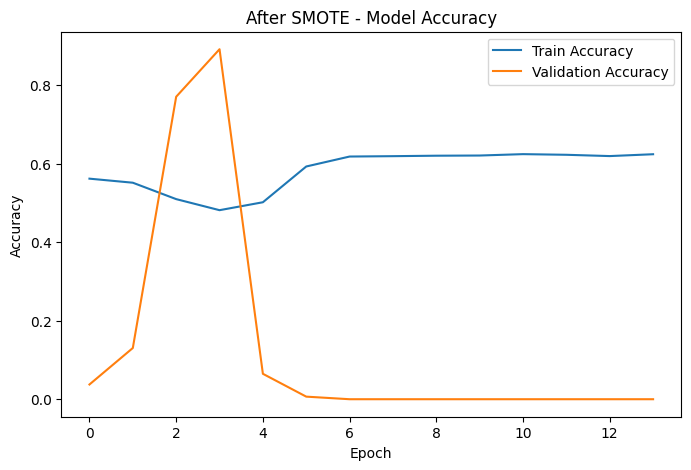

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Report (After SMOTE):
               precision    recall  f1-score   support

           0       0.34      0.81      0.48       341
           1       0.67      0.20      0.31       659

    accuracy                           0.41      1000
   macro avg       0.51      0.51      0.40      1000
weighted avg       0.56      0.41      0.37      1000

Confusion Matrix (After SMOTE):
 [[277  64]
 [527 132]]


In [ ]:
#Apply SMOTE to the **unscaled training data**
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 3. Standardize **after SMOTE**
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("Class distribution BEFORE SMOTE:\n", y_train.value_counts())
print("Class distribution AFTER SMOTE:\n", pd.Series(y_train_sm).value_counts())

# Build ANN model
model_sm = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_sm.shape[1],),
          kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile model
model_sm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop_sm = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history_sm = model_sm.fit(X_train_sm, y_train_sm, epochs=100, batch_size=32,
                          validation_split=0.2, callbacks=[early_stop_sm], verbose=1)

# Plot accuracy
plt.figure(figsize=(8,5))
plt.plot(history_sm.history['accuracy'], label='Train Accuracy')
plt.plot(history_sm.history['val_accuracy'], label='Validation Accuracy')
plt.title('After SMOTE - Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Predictions
y_pred_prob_sm = model_sm.predict(X_test_scaled)
y_pred_sm = (y_pred_prob_sm > 0.5).astype("int32")

# Evaluation
print("Classification Report (After SMOTE):\n", classification_report(y_test, y_pred_sm, zero_division=0))
print("Confusion Matrix (After SMOTE):\n", confusion_matrix(y_test, y_pred_sm))


In [ ]:

from sklearn.linear_model import LogisticRegression

In [ ]:
# Apply SMOTE on unscaled training data to balance classes
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Class distribution BEFORE SMOTE:\n", y_train.value_counts())
print("Class distribution AFTER SMOTE:\n", pd.Series(y_train_sm).value_counts())

# Standardize features
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Build Logistic Regression model
logreg = LogisticRegression(solver='liblinear', random_state=42)
logreg.fit(X_train_sm_scaled, y_train_sm)

# Predictions
y_pred = logreg.predict(X_test_scaled)
y_pred_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Classification Report - Logistic Regression:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix - Logistic Regression:\n", confusion_matrix(y_test, y_pred))

Class distribution BEFORE SMOTE:
 Outcome
1    2661
0    1339
Name: count, dtype: int64
Class distribution AFTER SMOTE:
 Outcome
1    2661
0    2661
Name: count, dtype: int64
Classification Report - Logistic Regression:
               precision    recall  f1-score   support

           0       0.33      0.50      0.39       341
           1       0.64      0.47      0.54       659

    accuracy                           0.48      1000
   macro avg       0.48      0.48      0.47      1000
weighted avg       0.53      0.48      0.49      1000

Confusion Matrix - Logistic Regression:
 [[169 172]
 [351 308]]
